In [1]:
# Notebooks live in Notebooks/, but every data path is relative to the repo root.
import os, sys
while not os.path.isdir("data") and os.getcwd() != "/":
    os.chdir("..")
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())
print("cwd:", os.getcwd())

cwd: /home/lotanamit/WhatDoLLMsWant


# Is the model additive, or does it use a priority list?

Everything so far fits an **additive** utility: `u = brand + screen + ram`. That model says
features **trade off** — enough brand advantage beats a RAM disadvantage.

This notebook asks whether that is true, and it is not. The models run a **priority list**
(a *lexicographic* rule): RAM decides; if RAM ties, screen mostly decides; brand only gets a
say when both are tied.

Then the question that matters for the thesis: **does stating a contract change the
priority?**

All of it is measured with **win rates only** — who the model picks. No Bradley-Terry, no
log-odds, no magnitudes. That matters, because the previous entry established that in this
data ranks are trustworthy and magnitudes are not.

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = ["data/laptops_robustness", "data/laptops_robustness_gemma"]
BRANDS = ["ASUS", "Apple", "Dell", "HP", "Lenovo"]
SC = ["13-inch", "14-inch", "16-inch"]
RM = ["4GB", "8GB", "16GB"]
RORD = {"4GB": 0, "8GB": 1, "16GB": 2}          # the natural "more is better" order
SORD = {"13-inch": 0, "14-inch": 1, "16-inch": 2}
CON = ["none", "screen=14-inch", "ram=8GB", "ram=8GB+screen=14-inch"]
CLAB = dict(zip(CON, ["none", "14in", "8GB", "14in+8GB"]))
SIZES = {"qwen": ["0.5", "7", "32", "72"], "gemma": ["1", "4", "12", "27"]}
# qwen-0.5B is noise on every measure (brand_consistency.ipynb) - excluded throughout.
REAL = [("qwen", s) for s in ["7", "32", "72"]] + [("gemma", s) for s in ["1", "4", "12", "27"]]

# Palette reused from the other laptop notebooks so the set reads as one system.
# Validated with the dataviz validator (all-pairs, light surface): 3 features PASS;
# the contract/own-preference pair PASS (CVD dE 21.6, normal 32.3).
FEATURE_COLOR = {"brand": "#2a78d6", "screen": "#eb6834", "ram": "#1baf7a"}
CONTRACT, OWN = "#2a78d6", "#e34948"
SURFACE, INK, INK_MUTED = "#fcfcfb", "#0b0b0b", "#52514e"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": "#d6d5d1", "axes.labelcolor": INK, "axes.titlecolor": INK,
    "text.color": INK, "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "axes.grid": True, "grid.color": "#e8e7e3", "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110,
})
pd.set_option("display.width", 220)


def load():
    R, C = {}, {}
    for b in BASE:
        for run in sorted(os.listdir(b)):
            cp = os.path.join(b, run, "config.json")
            if not os.path.isfile(cp):
                continue
            c = json.load(open(cp))
            k = (c["model_family"], str(c["model_size"]), c["constraints_id"])
            R[k] = pd.read_csv(os.path.join(b, run, "scores.csv"))
            C[k] = c["constraints"]
    return R, C


RUNS, CONSTRAINTS = load()
print(f"{len(RUNS)} runs")

32 runs


In [3]:
def margin(d):
    """>0 means the model picked option A."""
    return (d.score_a - d.score_b).values


def wins(d, mask, a_is_the_candidate):
    """% of the selected ordered pairs where the flagged laptop wins."""
    if mask.sum() == 0:
        return np.nan
    m, p = margin(d)[mask], a_is_the_candidate[mask]
    return 100 * float(np.mean(np.where(p, m > 0, m < 0)))


def pair_on(d, x, y, col):
    """The unordered pair {x, y} on one feature, in both slot orders."""
    return (((d[f"a_{col}"] == x) & (d[f"b_{col}"] == y))
            | ((d[f"a_{col}"] == y) & (d[f"b_{col}"] == x))).values


def complies(d, con, side):
    ok = np.ones(len(d), bool)
    for f, lvl in con.items():
        ok &= (d[f"{side}_{f}"] == lvl).values
    return ok

# 1. With no contract, RAM is a veto

A feature is **decisive** if the laptop with the better level of it wins whenever the two
laptops differ on it — no matter what the other features say. Check each feature in turn.

In [4]:
rows = []
for fam, s in REAL:
    d = RUNS[(fam, s, "none")]
    ra, rb = d.a_ram.map(RORD).values, d.b_ram.map(RORD).values
    sa, sb = d.a_screen.map(SORD).values, d.b_screen.map(SORD).values
    rows.append(dict(
        model=f"{fam}-{s}B",
        # RAM differs -> does more RAM win, whatever else is going on?
        ram=wins(d, ra != rb, ra > rb),
        # RAM tied, screen differs -> does the bigger screen win?
        screen=wins(d, (ra == rb) & (sa != sb), sa > sb),
    ))
DEC = pd.DataFrame(rows)
print("=== how often does the better level win, when that feature differs? ===")
print("(50% = the feature decides nothing;  100% = it always decides)\n")
print(DEC.round(1).to_string(index=False))
print("\nn per model: ram 6750 ordered pairs, screen 2100")

=== how often does the better level win, when that feature differs? ===
(50% = the feature decides nothing;  100% = it always decides)

    model   ram  screen
  qwen-7B 100.0    58.8
 qwen-32B 100.0    74.6
 qwen-72B 100.0    69.0
 gemma-1B  91.2    57.7
 gemma-4B  99.9    69.9
gemma-12B 100.0    77.9
gemma-27B 100.0    88.9

n per model: ram 6750 ordered pairs, screen 2100


In [5]:
print("=== is it just that 4GB is absurd? split by RAM step ===\n")
rows = []
for fam, s in REAL:
    d = RUNS[(fam, s, "none")]
    ra, rb = d.a_ram.map(RORD).values, d.b_ram.map(RORD).values
    r = {"model": f"{fam}-{s}B"}
    for lab, (lo, hi) in [("4 vs 8", (0, 1)), ("8 vs 16", (1, 2)), ("4 vs 16", (0, 2))]:
        m = ((ra == lo) & (rb == hi)) | ((ra == hi) & (rb == lo))
        r[lab] = wins(d, m, ra > rb)
    rows.append(r)
print(pd.DataFrame(rows).round(1).to_string(index=False))
print("\nEvery step is absolute, so this is not '4GB is silly'. More RAM simply always wins.")

=== is it just that 4GB is absurd? split by RAM step ===

    model  4 vs 8  8 vs 16  4 vs 16
  qwen-7B   100.0    100.0    100.0
 qwen-32B   100.0    100.0    100.0
 qwen-72B   100.0    100.0    100.0
 gemma-1B    82.4     91.6     99.7
 gemma-4B    99.8    100.0    100.0
gemma-12B   100.0    100.0    100.0
gemma-27B   100.0    100.0    100.0

Every step is absolute, so this is not '4GB is silly'. More RAM simply always wins.


In [6]:
print("=== and brand? Apple's win rate, by how close the rival is ===\n")
rows = []
for fam, s in REAL:
    d = RUNS[(fam, s, "none")]
    r = {"model": f"{fam}-{s}B"}
    for lab, m in [("RAM differs", (d.a_ram != d.b_ram).values),
                   ("RAM tied, screen differs",
                    ((d.a_ram == d.b_ram) & (d.a_screen != d.b_screen)).values),
                   ("RAM and screen tied", ((d.a_ram == d.b_ram)
                                            & (d.a_screen == d.b_screen)).values)]:
        mm = m & (d.a_brand != d.b_brand).values
        r[lab] = wins(d, mm, (d.a_brand == "Apple").values)
    rows.append(r)
APP = pd.DataFrame(rows)
print(APP.round(1).to_string(index=False))
print("\nBrand does nothing at all until the specs are tied.")

=== and brand? Apple's win rate, by how close the rival is ===

    model  RAM differs  RAM tied, screen differs  RAM and screen tied
  qwen-7B         50.0                      74.4                 78.7
 qwen-32B         50.0                      68.5                 75.1
 qwen-72B         50.0                      71.6                 79.4
 gemma-1B         54.6                      66.3                 52.1
 gemma-4B         50.0                      69.4                 72.3
gemma-12B         50.0                      65.0                 79.6
gemma-27B         50.0                      62.3                 86.3

Brand does nothing at all until the specs are tied.


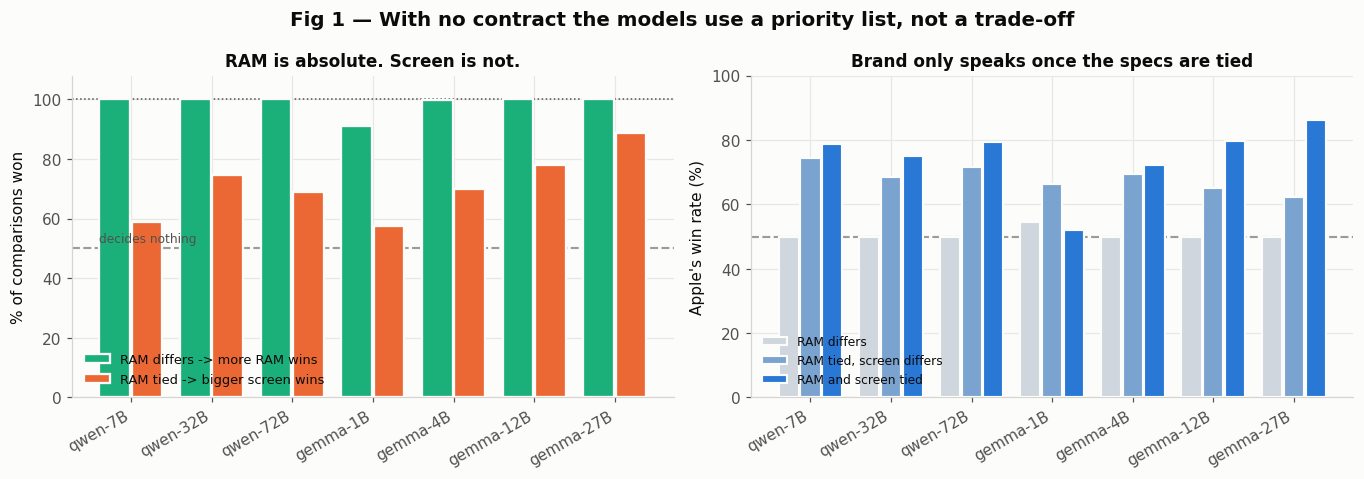

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
x = np.arange(len(DEC))

ax = axes[0]
ax.bar(x - 0.2, DEC.ram, 0.38, color=FEATURE_COLOR["ram"], edgecolor=SURFACE,
       linewidth=1.5, label="RAM differs -> more RAM wins", zorder=3)
ax.bar(x + 0.2, DEC.screen, 0.38, color=FEATURE_COLOR["screen"], edgecolor=SURFACE,
       linewidth=1.5, label="RAM tied -> bigger screen wins", zorder=3)
ax.axhline(50, color="#9c9b98", linewidth=1.4, linestyle="--")
ax.text(-0.4, 52, "decides nothing", ha="left", fontsize=8, color=INK_MUTED)
ax.axhline(100, color=INK_MUTED, linewidth=1, linestyle=":")
ax.set_xticks(x, DEC.model, rotation=30, ha="right")
ax.set_ylim(0, 108)
ax.set_ylabel("% of comparisons won")
ax.set_title("RAM is absolute. Screen is not.", fontsize=11, fontweight="bold")
ax.legend(fontsize=8.5, frameon=False, loc="lower left")

ax = axes[1]
cols = ["RAM differs", "RAM tied, screen differs", "RAM and screen tied"]
for i, (c, col) in enumerate(zip(cols, ["#cfd6de", "#7ba3d0", FEATURE_COLOR["brand"]])):
    ax.bar(x + (i - 1) * 0.27, APP[c], 0.25, color=col, edgecolor=SURFACE,
           linewidth=1.4, label=c, zorder=3)
ax.axhline(50, color="#9c9b98", linewidth=1.4, linestyle="--")
ax.set_xticks(x, APP.model, rotation=30, ha="right")
ax.set_ylabel("Apple's win rate (%)")
ax.set_title("Brand only speaks once the specs are tied", fontsize=11, fontweight="bold")
ax.set_ylim(0, 100)
ax.legend(fontsize=8, frameon=False, loc="lower left")

fig.suptitle("Fig 1 — With no contract the models use a priority list, not a trade-off",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**RAM wins 6750 out of 6750** for every model except the noisy gemma-1B. Not 99% — every
single comparison. Screen is different: 58-89%, so it can be overruled. Brand sits at
exactly **50.0%** whenever RAM differs, and only rises to 56-87% once the specs are tied.

The order is **RAM (absolute) > screen (partial) > brand (tie-breaker)**.

This is not an artifact of where the words sit in the sentence: the item text is
`"{screen} {brand} laptop with {ram} RAM"`, so the string order is screen, brand, ram —
which is not the priority order.

# 2. Why this breaks the additive model

An additive utility implies an **exchange rate**: so many units of brand buy one RAM step.
There is no exchange rate here — no amount of brand ever buys a RAM step.

The visible symptom: the "brand weight" depends entirely on which comparisons you feed the
fit, because it is averaging a regime where brand decides everything with one where it
decides nothing.

In [8]:
LEVELS = {"brand": BRANDS, "screen": SC, "ram": RM}


def fit_bt(df, feats=("brand", "screen", "ram")):
    """Sum-to-zero feature Bradley-Terry with a positional-bias intercept."""
    y = margin(df)
    cols, names = [np.ones(len(df))], ["gamma"]
    for f in feats:
        for l in LEVELS[f]:
            if l not in set(df["a_" + f]) | set(df["b_" + f]):
                continue
            cols.append((df["a_" + f].values == l).astype(float)
                        - (df["b_" + f].values == l).astype(float))
            names.append(f"{f}_{l}")
    X = np.column_stack(cols)
    w, *_ = np.linalg.lstsq(X, y, rcond=None)
    out = dict(zip(names, w))
    for f in feats:
        ks = [k for k in names if k.startswith(f + "_")]
        m = np.mean([out[k] for k in ks])
        for k in ks:
            out[k] -= m
    return out


rows = []
for fam, s in REAL:
    d = RUNS[(fam, s, "none")]
    sets = {"all 990 pairs": d,
            "same RAM": d[(d.a_ram == d.b_ram).values],
            "same RAM + screen": d[((d.a_ram == d.b_ram) & (d.a_screen == d.b_screen)).values]}
    r = {"model": f"{fam}-{s}B"}
    for k, dd in sets.items():
        feats = ("brand",) + tuple(f for f in ("screen", "ram")
                                   if (dd[f"a_{f}"] != dd[f"b_{f}"]).any())
        v = np.array([fit_bt(dd, feats)[f"brand_{x}"] for x in BRANDS])
        r[k] = v[1]
        r[k + " rank"] = 1 + (v > v[1]).sum()
    rows.append(r)
LAD = pd.DataFrame(rows)
print("=== Apple's fitted brand weight, same data, different comparison sets ===")
print(LAD[["model", "all 990 pairs", "same RAM", "same RAM + screen"]].round(2).to_string(index=False))
print("\n=== Apple's RANK in the same three sets ===")
print(LAD[["model", "all 990 pairs rank", "same RAM rank",
           "same RAM + screen rank"]].to_string(index=False))

# is this collinearity? no - the design is a full factorial
d = RUNS[("qwen", "32", "none")]
ba = np.column_stack([(d.a_brand == l).astype(float) - (d.b_brand == l).astype(float) for l in BRANDS])
ra = np.column_stack([(d.a_ram == l).astype(float) - (d.b_ram == l).astype(float) for l in RM])
print(f"\nmax |correlation| between any brand column and any RAM column: "
      f"{np.abs(np.corrcoef(np.column_stack([ba, ra]).T)[:5, 5:]).max():.4f}")
print("-> exactly orthogonal, so the shift above is real, not collinearity.")

=== Apple's fitted brand weight, same data, different comparison sets ===
    model  all 990 pairs  same RAM  same RAM + screen
  qwen-7B           0.46      1.62               3.24
 qwen-32B           2.21      5.16               7.31
 qwen-72B           1.95      4.27               5.09
 gemma-1B           1.35      2.77               3.64
 gemma-4B           1.73      4.86               6.02
gemma-12B           1.28      2.64               3.41
gemma-27B           2.74      7.98              10.79

=== Apple's RANK in the same three sets ===
    model  all 990 pairs rank  same RAM rank  same RAM + screen rank
  qwen-7B                   1              1                       1
 qwen-32B                   1              1                       1
 qwen-72B                   1              1                       1
 gemma-1B                   1              1                       1
 gemma-4B                   1              1                       1
gemma-12B                   1      

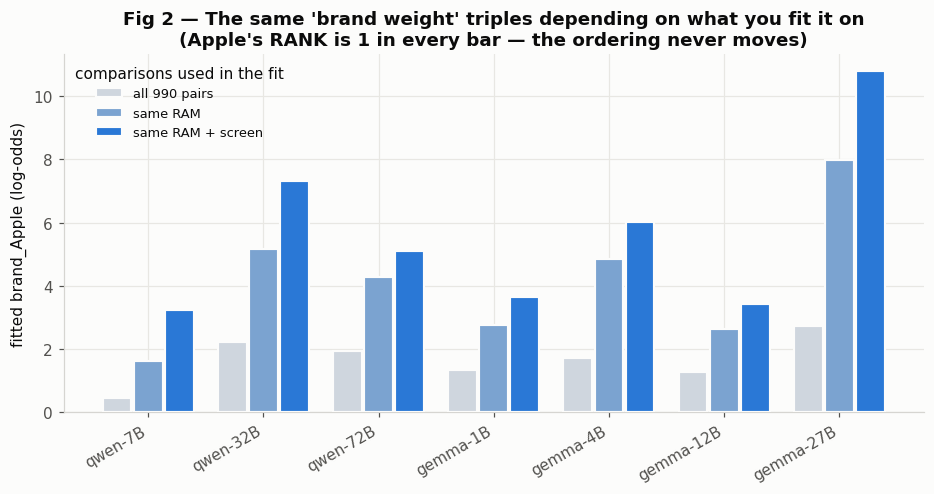

In [9]:
fig, ax = plt.subplots(figsize=(8.6, 4.6))
cols = ["all 990 pairs", "same RAM", "same RAM + screen"]
x = np.arange(len(LAD))
for i, (c, col) in enumerate(zip(cols, ["#cfd6de", "#7ba3d0", FEATURE_COLOR["brand"]])):
    ax.bar(x + (i - 1) * 0.27, LAD[c], 0.25, color=col, edgecolor=SURFACE,
           linewidth=1.4, label=c, zorder=3)
ax.set_xticks(x, LAD.model, rotation=30, ha="right")
ax.set_ylabel("fitted brand_Apple (log-odds)")
ax.legend(title="comparisons used in the fit", fontsize=8.5, frameon=False)
ax.set_title("Fig 2 — The same 'brand weight' triples depending on what you fit it on\n"
             "(Apple's RANK is 1 in every bar — the ordering never moves)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

Apple's weight roughly **triples** from "all pairs" to "specs tied", and brand is exactly
orthogonal to RAM in the design, so this is not collinearity. It is the additive model
averaging two regimes that have nothing in common.

**Apple's rank is 1 in all three sets, for all seven models.** Ranking survives; the number
does not. Never quote a brand weight without saying which comparisons produced it.

# 3. Does a contract change the priority order?

The prediction was: *the contracted feature jumps to the top of the list.*

There is a clean way to test it. Under the `ram=8GB` contract the contract and the model's
own order **point at different laptops**:

| pair | contract says | the model's own order says |
|---|---|---|
| 8GB vs 16GB | **8GB** (it complies) | **16GB** (more RAM always wins) |
| 8GB vs 4GB | 8GB | 8GB — they agree, tells us nothing |
| 4GB vs 16GB | silent — neither complies | 16GB |

So look at **8GB vs 16GB** and see who actually wins.

In [10]:
rows = []
for fam, s in REAL:
    r = {"model": f"{fam}-{s}B"}
    for lab, key in [("no contract", "none"), ("under ram=8GB", "ram=8GB")]:
        d = RUNS[(fam, s, key)]
        r[lab] = wins(d, pair_on(d, "8GB", "16GB", "ram"), (d.a_ram == "8GB").values)
    d = RUNS[(fam, s, "ram=8GB")]
    r["4 vs 16 (contract silent)"] = wins(d, pair_on(d, "4GB", "16GB", "ram"),
                                          (d.a_ram == "16GB").values)
    r["8 vs 4 (they agree)"] = wins(d, pair_on(d, "8GB", "4GB", "ram"),
                                    (d.a_ram == "8GB").values)
    rows.append(r)
CONF = pd.DataFrame(rows)
print("=== 8GB vs 16GB: does the contract beat the model's own RAM veto? ===")
print("(% where the 8GB laptop - the compliant one - wins)\n")
print(CONF[["model", "no contract", "under ram=8GB"]].round(1).to_string(index=False))
print("\n=== control: the same run, where the contract has nothing to say ===")
print("(% where the laptop the model's OWN order prefers wins)\n")
print(CONF[["model", "4 vs 16 (contract silent)", "8 vs 4 (they agree)"]].round(1).to_string(index=False))

=== 8GB vs 16GB: does the contract beat the model's own RAM veto? ===
(% where the 8GB laptop - the compliant one - wins)

    model  no contract  under ram=8GB
  qwen-7B          0.0           60.0
 qwen-32B          0.0           59.1
 qwen-72B          0.0           84.8
 gemma-1B          8.4           10.0
 gemma-4B          0.0           15.9
gemma-12B          0.0           54.5
gemma-27B          0.0           93.2

=== control: the same run, where the contract has nothing to say ===
(% where the laptop the model's OWN order prefers wins)

    model  4 vs 16 (contract silent)  8 vs 4 (they agree)
  qwen-7B                      100.0                100.0
 qwen-32B                      100.0                100.0
 qwen-72B                       97.1                100.0
 gemma-1B                       98.7                 96.9
 gemma-4B                      100.0                100.0
gemma-12B                      100.0                100.0
gemma-27B                      100.0    

In [11]:
print("=== the same conflict for the SCREEN contract ===")
print("Among RAM-tied pairs, 14-inch vs 16-inch. The models' own order prefers the bigger screen.")
print("(% where the 14-inch - the compliant one - wins)\n")
rows = []
for fam, s in REAL:
    r = {"model": f"{fam}-{s}B"}
    for lab, key in [("no contract", "none"), ("under screen=14-inch", "screen=14-inch")]:
        d = RUNS[(fam, s, key)]
        m = pair_on(d, "14-inch", "16-inch", "screen") & (d.a_ram == d.b_ram).values
        r[lab] = wins(d, m, (d.a_screen == "14-inch").values)
    rows.append(r)
SCR = pd.DataFrame(rows)
print(SCR.round(1).to_string(index=False))

=== the same conflict for the SCREEN contract ===
Among RAM-tied pairs, 14-inch vs 16-inch. The models' own order prefers the bigger screen.
(% where the 14-inch - the compliant one - wins)



    model  no contract  under screen=14-inch
  qwen-7B         39.3                  96.4
 qwen-32B         29.2                 100.0
 qwen-72B         34.0                 100.0
 gemma-1B         45.5                  37.1
 gemma-4B         24.8                  49.7
gemma-12B         20.5                 100.0
gemma-27B         11.2                 100.0


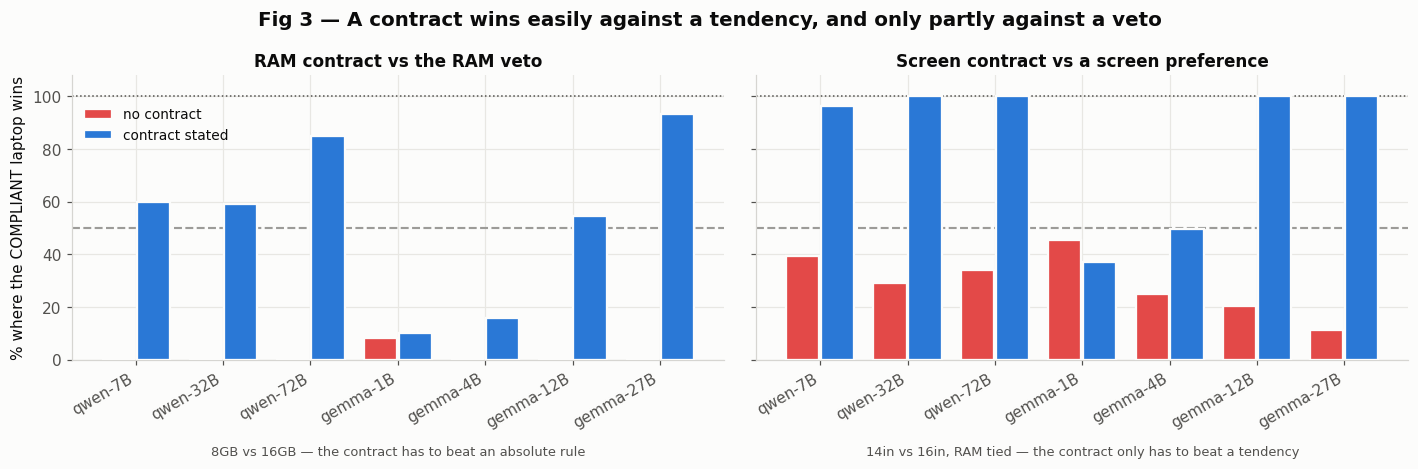

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
for ax, (T, a, b, title, sub) in zip(axes, [
        (CONF, "no contract", "under ram=8GB",
         "RAM contract vs the RAM veto",
         "8GB vs 16GB — the contract has to beat an absolute rule"),
        (SCR, "no contract", "under screen=14-inch",
         "Screen contract vs a screen preference",
         "14in vs 16in, RAM tied — the contract only has to beat a tendency")]):
    x = np.arange(len(T))
    ax.bar(x - 0.2, T[a], 0.38, color=OWN, edgecolor=SURFACE, linewidth=1.5,
           label="no contract", zorder=3)
    ax.bar(x + 0.2, T[b], 0.38, color=CONTRACT, edgecolor=SURFACE, linewidth=1.5,
           label="contract stated", zorder=3)
    ax.axhline(50, color="#9c9b98", linewidth=1.4, linestyle="--")
    ax.axhline(100, color=INK_MUTED, linewidth=1, linestyle=":")
    ax.set_xticks(x, T.model, rotation=30, ha="right")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.text(0.5, -0.30, sub, transform=ax.transAxes, ha="center", va="top",
            fontsize=8.5, color=INK_MUTED)
    ax.set_ylim(0, 108)
axes[0].set_ylabel("% where the COMPLIANT laptop wins")
axes[0].legend(fontsize=9, frameon=False, loc="upper left", bbox_to_anchor=(0.0, 0.93))
fig.suptitle("Fig 3 — A contract wins easily against a tendency, and only partly "
             "against a veto", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**The prediction was half right.**

- **Against the screen preference** (which was only a tendency, 58-89%), the contract
  installs a **new absolute veto**: 14-inch goes from winning 11-45% to **96-100%** for
  qwen-7/32/72B and gemma-12/27B. The order really does change.
- **Against the RAM veto**, the contract does *not* take the top slot. 8GB goes from
  **0%** to 54-93%. The veto is broken, but nothing replaces it — RAM and compliance now
  genuinely **trade off**.
- Where the contract says nothing (4GB vs 16GB), the RAM veto is **untouched**: 97-100%.
  So the contract does not make the model generally erratic; it acts only where it applies.

The reading: **a contract's power depends on what it is fighting.** Asking for something the
model was flexible about is obeyed completely. Asking it to give up the thing it always wants
is obeyed only partly — and how partly depends on the model.

# 4. Contract override rate — adherence as a behaviour

This gives a better adherence metric than the fitted weight. Take every pair where the
contract and the model's own RAM order point at **different** laptops, and ask how often the
contract wins. It is a percentage, it needs no model, and it cannot be inflated by the
log-odds scale.

In [13]:
rows = []
for fam, s in REAL:
    r = {"model": f"{fam}-{s}B", "family": fam, "size": float(s)}
    for key in ["screen=14-inch", "ram=8GB", "ram=8GB+screen=14-inch"]:
        d, con = RUNS[(fam, s, key)], CONSTRAINTS[(fam, s, key)]
        ca, cb = complies(d, con, "a"), complies(d, con, "b")
        ra, rb = d.a_ram.map(RORD).values, d.b_ram.map(RORD).values
        # exactly one complies, and the compliant one has LESS ram -> a real conflict
        m = ((ca & ~cb) & (ra < rb)) | ((cb & ~ca) & (rb < ra))
        r[CLAB[key]] = wins(d, m, ca)
    rows.append(r)
OVR = pd.DataFrame(rows)
print("=== contract override rate (%) ===")
print("pairs where the compliant laptop has LESS RAM than the non-compliant one\n")
print(OVR[["model", "14in", "8GB", "14in+8GB"]].round(1).to_string(index=False))
for fam in ["qwen", "gemma"]:
    sub = OVR[OVR.family == fam].sort_values("size")
    print(f"\n  {fam}, override on the 8GB contract: "
          + "  ".join(f"{r['size']:g}B={r['8GB']:.0f}%" for _, r in sub.iterrows()))

=== contract override rate (%) ===
pairs where the compliant laptop has LESS RAM than the non-compliant one

    model  14in  8GB  14in+8GB
  qwen-7B  24.9 60.0      71.2
 qwen-32B  68.7 59.1      79.3
 qwen-72B  64.7 84.8      83.3
 gemma-1B   7.3 10.0      18.3
 gemma-4B  16.9 15.9      53.9
gemma-12B  57.3 54.5      82.4
gemma-27B  85.0 93.2      84.3

  qwen, override on the 8GB contract: 7B=60%  32B=59%  72B=85%

  gemma, override on the 8GB contract: 1B=10%  4B=16%  12B=54%  27B=93%


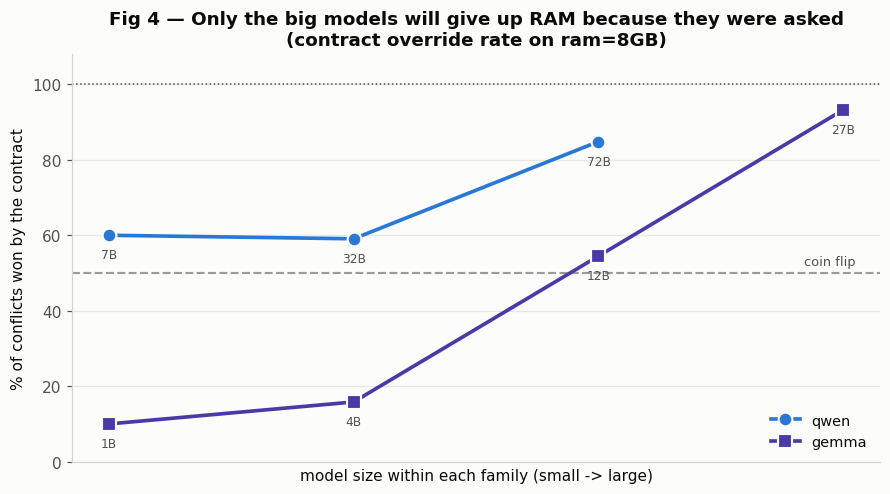

In [14]:
fig, ax = plt.subplots(figsize=(8.2, 4.6))
for fam, col, mk in [("qwen", "#2a78d6", "o"), ("gemma", "#4a3aa7", "s")]:
    sub = OVR[OVR.family == fam].sort_values("size")
    ax.plot(np.arange(len(sub)), sub["8GB"], marker=mk, markersize=9, linewidth=2.4,
            color=col, markeredgecolor=SURFACE, markeredgewidth=1.4, label=fam, zorder=3)
    for i, (_, r) in enumerate(sub.iterrows()):
        ax.annotate(f"{r['size']:g}B", (i, r["8GB"]), textcoords="offset points",
                    xytext=(0, -15), ha="center", fontsize=8, color=INK_MUTED)
ax.axhline(50, color="#9c9b98", linewidth=1.4, linestyle="--")
ax.text(3.05, 52, "coin flip", ha="right", fontsize=8.5, color=INK_MUTED)
ax.axhline(100, color=INK_MUTED, linewidth=1, linestyle=":")
ax.set_xticks([])
ax.set_xlabel("model size within each family (small -> large)")
ax.set_ylabel("% of conflicts won by the contract")
ax.set_ylim(0, 108)
ax.legend(frameon=False, fontsize=9.5)
ax.set_title("Fig 4 — Only the big models will give up RAM because they were asked\n"
             "(contract override rate on ram=8GB)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

gemma is monotonic in size — **10% → 16% → 54% → 93%**. qwen goes 60% → 59% → 85%.

The small models are not "less obedient" in a vague sense. They fail at exactly one thing:
**overruling their own strongest preference when the user asks them to.** Where the contract
does not conflict with that preference, even gemma-1B complies (97-100% on the control).

# Summary

1. **The models are lexicographic, not additive.** With no contract, more RAM wins
   **6750/6750** comparisons — every step, including 8 vs 16. Screen is a tendency
   (58-89%). Brand sits at exactly **50.0%** until the specs are tied.
2. **So the additive utility has no exchange rate.** `brand_Apple = +2.21` against a RAM
   spread of 25 implies a trade the model will never make at any price. The fitted brand
   weight **triples** (+2.21 → +7.31 for qwen-32B) depending only on which comparisons enter
   the fit, while Apple's **rank stays 1 in every case**.
3. **A contract's power depends on what it fights.** Against the screen *tendency* it
   installs a new absolute veto (11-45% → **96-100%**). Against the RAM *veto* it only bends
   it (0% → 54-93%). Where the contract is silent, the veto is untouched (97-100%).
4. **Override rate is a better adherence metric than the weight** — a percentage, model-free,
   immune to the scale problem. It scales sharply with size (gemma 10 → 93%).

**For the contract-theory frame:** the agent does not maximise a weighted utility that the
contract shifts. It has a priority order, and the contract inserts itself into that order —
completely where the agent was flexible, partially where the agent had a hard rule. This is
also why C6 looked the way it did: naming RAM promotes an absolute filter above brand, while
naming screen promotes something brand could still sometimes beat.

### Open

- Does the override rate keep rising above 72B, or saturate?
- `ram=16GB` (not yet collected) is the case where contract and the model's own order
  **agree**. Prediction: near-100% compliance for every model, including gemma-1B — because
  nothing has to be given up. That isolates "obeying" from "sacrificing".
- Check the lexicographic structure on the earlier colors/foods/cars sets: is it general, or
  a property of these three very legible laptop features?